# 🔬 Ten-Crop No-Flip Visualizer
### Verify spatial crop coverage on H&E patches for MSI prediction pipeline

This notebook lets you:
1. Load any single patch image
2. Visualise all **10 crop bounding boxes** on the original patch
3. Inspect each of the **10 individual crops** side-by-side
4. Check the **pairwise IoU overlap matrix** to confirm spatial diversity

> **Strategy:** 4 corners + 4 edge midpoints + 1 true center + 1 inner-offset center (no flipping)

## 1 · Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image

# Inline plots
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 2 · Configuration

Set your patch path and crop size here. All other cells read from these variables.

In [2]:
# ── USER SETTINGS ────────────────────────────────────────────────────────
PATCH_PATH = r"D:\Aamir Gulzar\KSA_project2\dataset\patch_data\TCGA-3L-AA1B_nonMSIH\TCGA-3L-AA1B_nonMSIH_x2608_y14048_patch00000.png"   # ← change this to your patch file
CROP_SIZE  = 256                          # 256 for 512×512 patches (matches paper)
                                          # 224 if your patches are already 224-sized
# ─────────────────────────────────────────────────────────────────────────

print(f"Patch path : {PATCH_PATH}")
print(f"Crop size  : {CROP_SIZE} × {CROP_SIZE} px")
print(f"Offset     : {CROP_SIZE // 4} px  (crop_size // 4 diagonal shift for crop 10)")

Patch path : D:\Aamir Gulzar\KSA_project2\dataset\patch_data\TCGA-3L-AA1B_nonMSIH\TCGA-3L-AA1B_nonMSIH_x2608_y14048_patch00000.png
Crop size  : 256 × 256 px
Offset     : 64 px  (crop_size // 4 diagonal shift for crop 10)


## 3 · Ten-Crop No-Flip Logic

The `TenCropNoFlip` class computes the 10 crop positions.  
`get_crop_coords()` returns coordinates + labels + colours so the visualiser
can draw everything without re-running the crop logic.

In [3]:
class TenCropNoFlip:
    """
    10 spatial crops from a single patch — NO flipping of any kind.

    Positions
    ---------
    1  Top-Left corner
    2  Top-Right corner
    3  Bottom-Left corner
    4  Bottom-Right corner
    5  Top-Center   (top edge midpoint)
    6  Bottom-Center (bottom edge midpoint)
    7  Middle-Left  (left edge midpoint)
    8  Middle-Right (right edge midpoint)
    9  True Center
    10 Inner-Offset Center  (center + crop_size//4 diagonally ↘)

    Why NOT transforms.TenCrop?
    ---------------------------
    PyTorch's TenCrop = 5 original crops + 5 horizontally flipped copies.
    That introduces flip augmentation, which we explicitly avoid here.
    """

    # One colour per crop — visually distinct, colourblind-friendly palette
    COLORS = [
        "#E74C3C",   # 1  Top-Left        red
        "#E67E22",   # 2  Top-Right        orange
        "#F1C40F",   # 3  Bottom-Left      yellow
        "#2ECC71",   # 4  Bottom-Right     green
        "#1ABC9C",   # 5  Top-Center       teal
        "#3498DB",   # 6  Bottom-Center    blue
        "#9B59B6",   # 7  Middle-Left      purple
        "#E91E63",   # 8  Middle-Right     pink
        "#FFFFFF",   # 9  True Center      white
        "#00BCD4",   # 10 Offset Center    cyan
    ]

    LABELS = [
        "1 · Top-Left",
        "2 · Top-Right",
        "3 · Bottom-Left",
        "4 · Bottom-Right",
        "5 · Top-Center",
        "6 · Bottom-Center",
        "7 · Middle-Left",
        "8 · Middle-Right",
        "9 · True Center",
        "10 · Offset Center ↘",
    ]

    def __init__(self, crop_size: int = 256):
        self.crop_size = crop_size

    def _clamp(self, v: int, lo: int, hi: int) -> int:
        return max(lo, min(v, hi))

    def get_crop_coords(self, W: int, H: int):
        """
        Returns list of dicts, one per crop:
            { 'left', 'top', 'label', 'color' }
        """
        c      = self.crop_size
        offset = c // 4

        raw = [
            (0,                   0                  ),   # 1
            (W - c,               0                  ),   # 2
            (0,                   H - c              ),   # 3
            (W - c,               H - c              ),   # 4
            ((W - c) // 2,        0                  ),   # 5
            ((W - c) // 2,        H - c              ),   # 6
            (0,                   (H - c) // 2       ),   # 7
            (W - c,               (H - c) // 2       ),   # 8
            ((W - c) // 2,        (H - c) // 2       ),   # 9
            ((W - c) // 2 + offset, (H - c) // 2 + offset),  # 10
        ]

        return [
            {
                "left":  self._clamp(l, 0, W - c),
                "top":   self._clamp(t, 0, H - c),
                "label": self.LABELS[i],
                "color": self.COLORS[i],
            }
            for i, (l, t) in enumerate(raw)
        ]

    def __call__(self, img: Image.Image):
        """
        Returns (crops, coords):
            crops  — list of 10 PIL Images
            coords — list of 10 coord dicts
        """
        W, H = img.size
        c    = self.crop_size

        if W < c or H < c:
            raise ValueError(
                f"Image ({W}×{H}) is smaller than crop_size ({c}). "
                f"Reduce CROP_SIZE or use a larger patch."
            )

        coords = self.get_crop_coords(W, H)
        crops  = [
            img.crop((d["left"], d["top"],
                      d["left"] + c, d["top"] + c))
            for d in coords
        ]
        return crops, coords


print("✅  TenCropNoFlip class defined.")

✅  TenCropNoFlip class defined.


## 4 · Load & Inspect the Patch

Loaded : TCGA-3L-AA1B_nonMSIH_x2608_y14048_patch00000.png
Size   : 512 × 512 px
Mode   : RGB


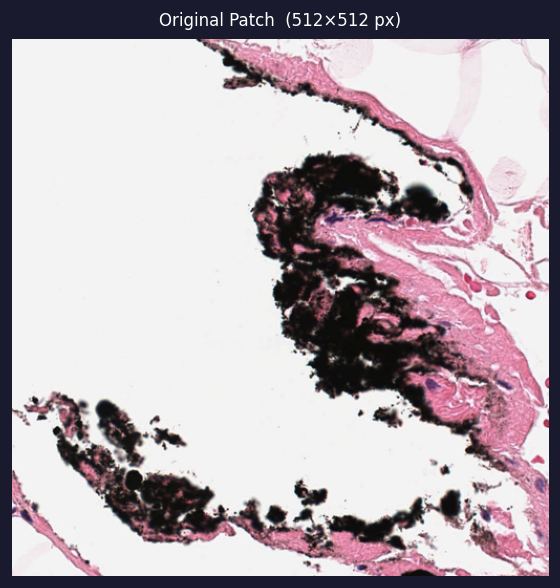

In [4]:
img  = Image.open(PATCH_PATH).convert("RGB")
W, H = img.size

print(f"Loaded : {os.path.basename(PATCH_PATH)}")
print(f"Size   : {W} × {H} px")
print(f"Mode   : {img.mode}")

# Quick preview of the raw patch
fig, ax = plt.subplots(1, 1, figsize=(5, 5), facecolor="#1a1a2e")
ax.imshow(np.array(img))
ax.set_title(f"Original Patch  ({W}×{H} px)",
             color="white", fontsize=10, pad=8)
ax.axis("off")
fig.tight_layout()
plt.show()

## 5 · Apply Ten-Crop

In [5]:
ten_crop       = TenCropNoFlip(crop_size=CROP_SIZE)
crops, coords  = ten_crop(img)

print(f"{'#':<4} {'Label':<24} {'Top-Left':>12}   {'Bottom-Right':>14}")
print("─" * 60)
for i, d in enumerate(coords):
    br = (d['left'] + CROP_SIZE, d['top'] + CROP_SIZE)
    print(f"{i+1:<4} {d['label']:<24} ({d['left']:>4}, {d['top']:>4})   "
          f"({br[0]:>4}, {br[1]:>4})")

#    Label                        Top-Left     Bottom-Right
────────────────────────────────────────────────────────────
1    1 · Top-Left             (   0,    0)   ( 256,  256)
2    2 · Top-Right            ( 256,    0)   ( 512,  256)
3    3 · Bottom-Left          (   0,  256)   ( 256,  512)
4    4 · Bottom-Right         ( 256,  256)   ( 512,  512)
5    5 · Top-Center           ( 128,    0)   ( 384,  256)
6    6 · Bottom-Center        ( 128,  256)   ( 384,  512)
7    7 · Middle-Left          (   0,  128)   ( 256,  384)
8    8 · Middle-Right         ( 256,  128)   ( 512,  384)
9    9 · True Center          ( 128,  128)   ( 384,  384)
10   10 · Offset Center ↘     ( 192,  192)   ( 448,  448)


## 6 · Main Visualisation — Bounding Boxes on Original Patch

Each crop is drawn as a **coloured rectangle** on the original patch.  
Numbers inside each box correspond to the crop index.  
The **white crosshair** marks the exact centre of the patch.

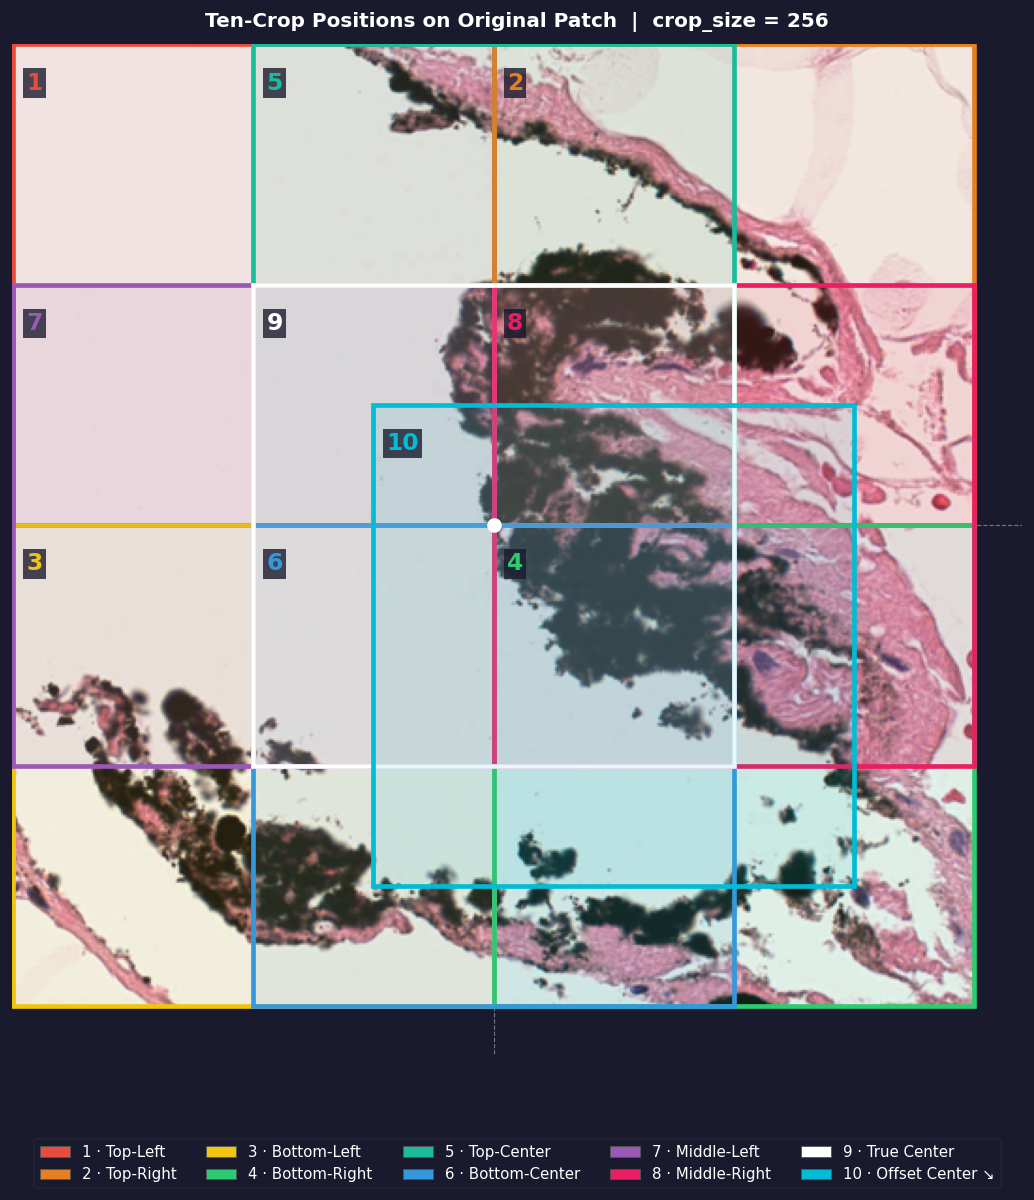

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), facecolor="#1a1a2e")
ax.imshow(np.array(img))
ax.set_title(
    f"Ten-Crop Positions on Original Patch  |  crop_size = {CROP_SIZE}",
    color="white", fontsize=12, pad=10, fontweight="bold"
)
ax.axis("off")

for i, d in enumerate(coords):
    l, t, c_col = d["left"], d["top"], d["color"]

    # Rectangle
    rect = mpatches.FancyBboxPatch(
        (l, t), CROP_SIZE, CROP_SIZE,
        linewidth=2.8,
        edgecolor=c_col,
        facecolor=c_col + "18",
        boxstyle="square,pad=0",
        zorder=3
    )
    ax.add_patch(rect)

    # Crop index label
    ax.text(
        l + 7, t + 24,
        str(i + 1),
        color=c_col,
        fontsize=14,
        fontweight="bold",
        zorder=4,
        bbox=dict(facecolor="#1a1a2eCC", edgecolor="none", pad=2)
    )

# Centre crosshair
cx, cy = W / 2, H / 2
ax.axhline(cy, color="white", linewidth=0.7, linestyle="--", alpha=0.4)
ax.axvline(cx, color="white", linewidth=0.7, linestyle="--", alpha=0.4)
ax.scatter([cx], [cy], color="white", s=60, zorder=5)

# Legend
handles = [
    mpatches.Patch(facecolor=d["color"], edgecolor="#555",
                   linewidth=0.5, label=d["label"])
    for d in coords
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=5,
    fontsize=9,
    framealpha=0.15,
    labelcolor="white",
    facecolor="#1a1a2e",
    edgecolor="#555"
)

plt.tight_layout()
plt.show()

## 7 · Individual Crop Grid (2 × 5)

Each crop is shown with its **colour-coded border**, label, and exact
**top-left pixel coordinate** so you can cross-reference with the bounding
box panel above.

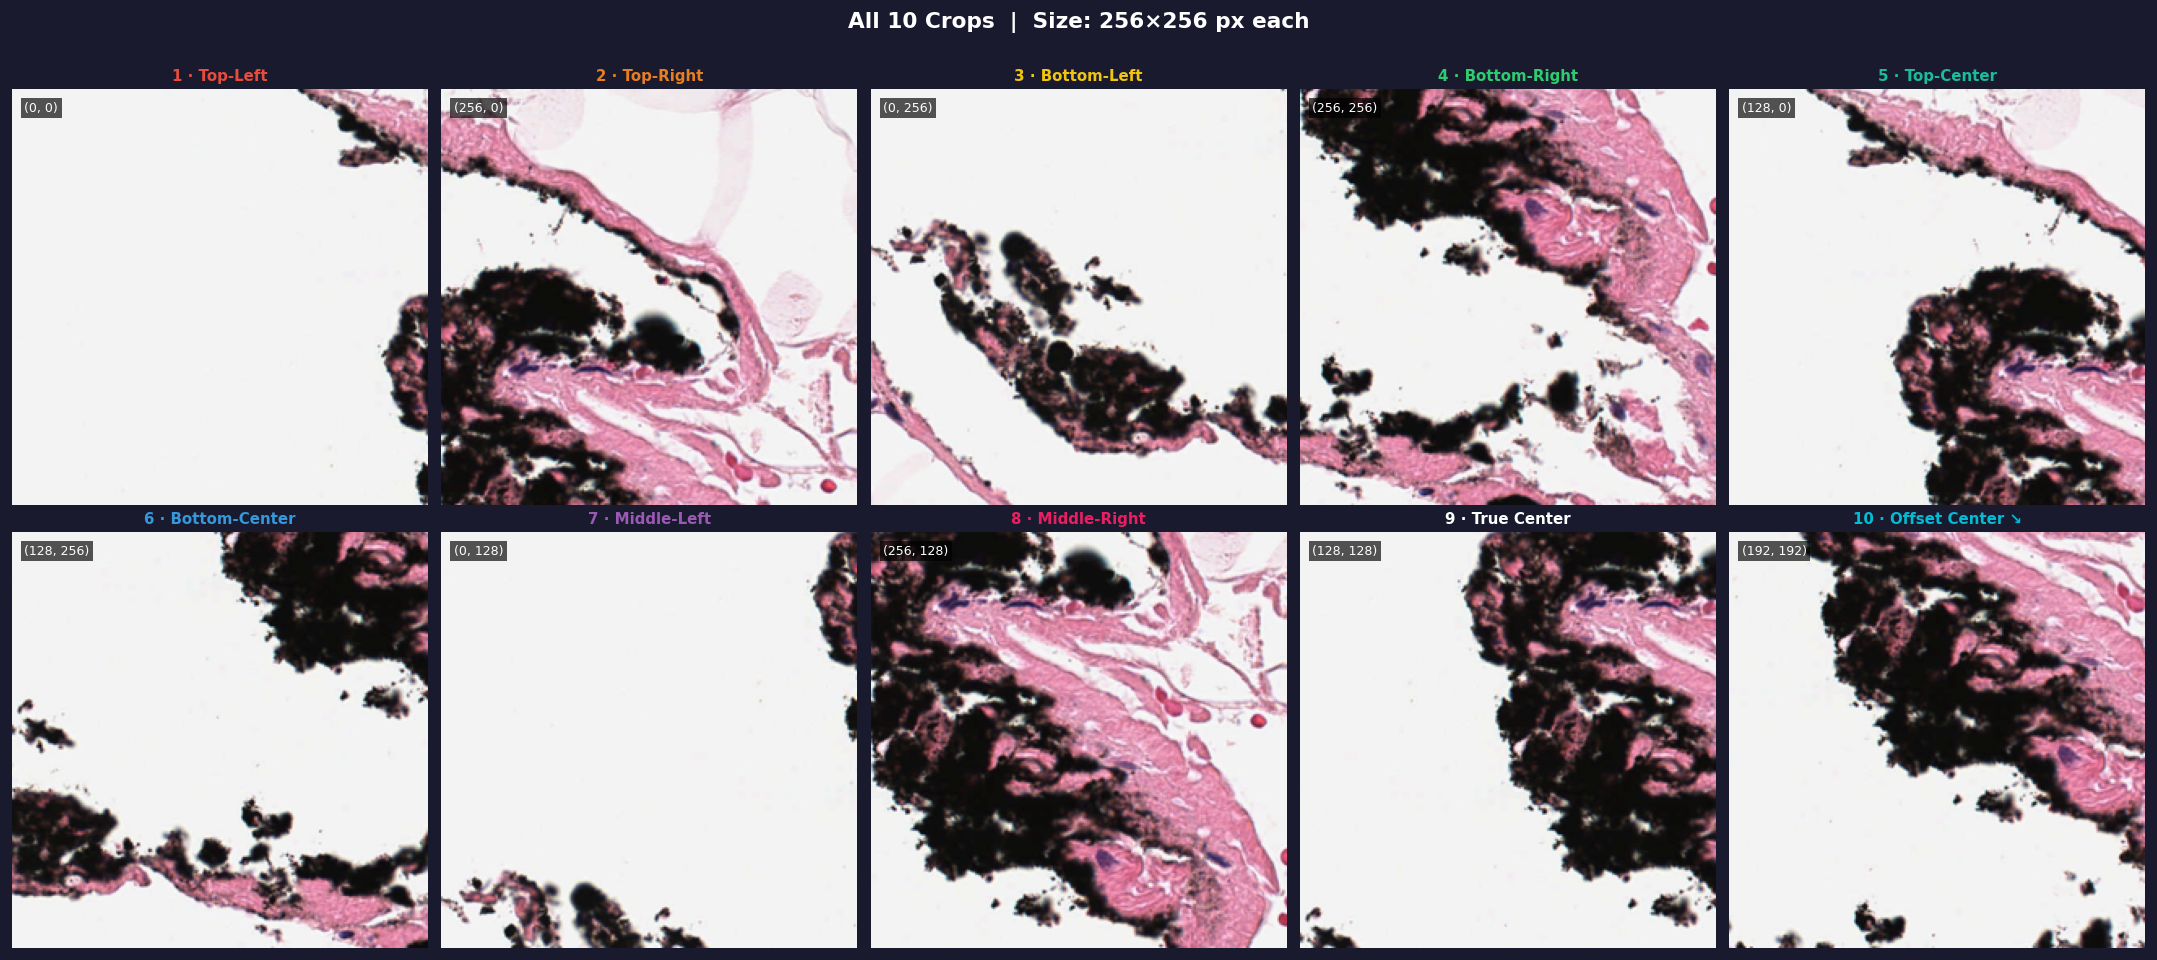

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), facecolor="#1a1a2e")
fig.suptitle(
    f"All 10 Crops  |  Size: {CROP_SIZE}×{CROP_SIZE} px each",
    color="white", fontsize=13, fontweight="bold", y=1.01
)

for idx, (crop_img, d) in enumerate(zip(crops, coords)):
    row, col = divmod(idx, 5)
    ax = axes[row][col]

    ax.imshow(np.array(crop_img))
    ax.set_title(d["label"], color=d["color"],
                 fontsize=9, fontweight="bold", pad=5)
    ax.axis("off")
    ax.set_facecolor("#1a1a2e")

    # Coloured border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(d["color"])
        spine.set_linewidth(3)

    # Top-left coordinate watermark
    ax.text(
        0.03, 0.97,
        f"({d['left']}, {d['top']})",
        transform=ax.transAxes,
        color="white", fontsize=7.5, va="top",
        bbox=dict(facecolor="#000000AA", edgecolor="none", pad=2)
    )

plt.tight_layout(pad=0.8)
plt.show()

## 8 · Centre vs Offset-Centre Close-Up

Crops **9** (true centre) and **10** (offset centre ↘) are the most similar.
This cell shows them side-by-side with a **difference heatmap** so you can
verify that the offset introduces a genuinely distinct spatial window.

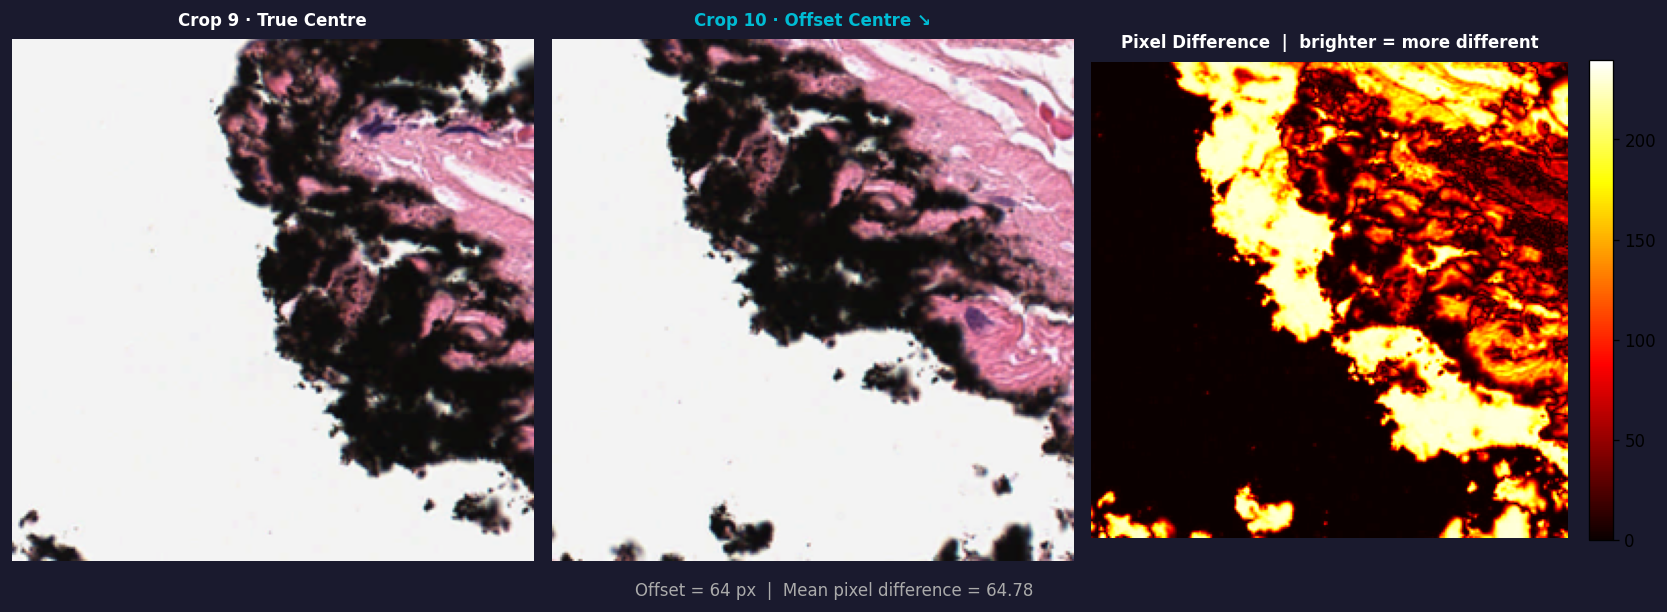

In [8]:
cc  = np.array(crops[8]).astype(float)   # crop 9 — true centre
cc2 = np.array(crops[9]).astype(float)   # crop 10 — offset centre

diff = np.abs(cc - cc2).mean(axis=2)     # mean-channel absolute difference

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="#1a1a2e")

titles  = ["Crop 9 · True Centre", "Crop 10 · Offset Centre ↘",
           "Pixel Difference  |  brighter = more different"]
images  = [crops[8], crops[9], None]
colors  = [coords[8]["color"], coords[9]["color"], "white"]

for ax, title, img_data, col in zip(axes, titles, images, colors):
    if img_data is not None:
        ax.imshow(np.array(img_data))
    else:
        im = ax.imshow(diff, cmap="hot", vmin=0, vmax=diff.max())
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, color=col, fontsize=10, fontweight="bold", pad=8)
    ax.axis("off")
    ax.set_facecolor("#1a1a2e")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(col)
        spine.set_linewidth(2.5)

fig.suptitle(
    f"Offset = {CROP_SIZE // 4} px  |  Mean pixel difference = {diff.mean():.2f}",
    color="#aaaaaa", fontsize=10, y=0
)
plt.tight_layout()
plt.show()

## 9 · Pairwise IoU Overlap Matrix

Low IoU = spatially diverse crops. This heatmap confirms how much any two
crops overlap. Diagonal is always 1.0 (a crop with itself).

> Ideal: off-diagonal values should be **low** for most pairs, with only
> crops 9 & 10 (centre pair) showing moderate overlap.

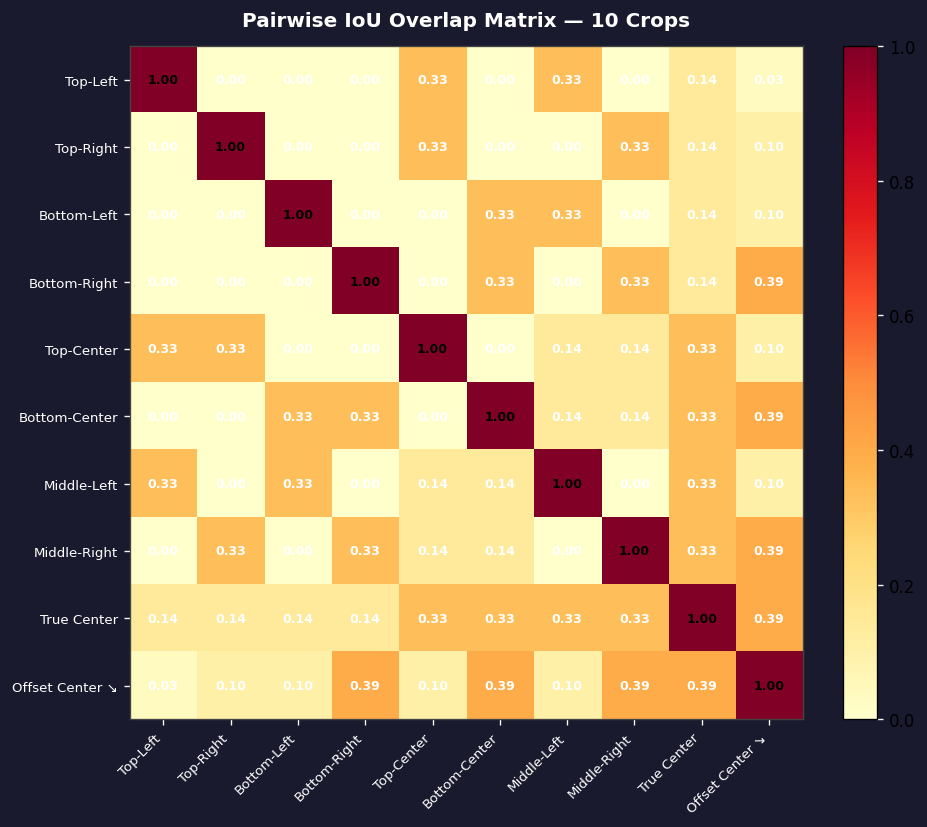

Mean off-diagonal IoU : 0.1590  (lower = more spatially diverse crops)


In [9]:
n   = len(coords)
iou = np.zeros((n, n))

for i, di in enumerate(coords):
    for j, dj in enumerate(coords):
        # Intersection rectangle
        ix = max(0, min(di["left"] + CROP_SIZE, dj["left"] + CROP_SIZE)
                    - max(di["left"], dj["left"]))
        iy = max(0, min(di["top"]  + CROP_SIZE, dj["top"]  + CROP_SIZE)
                    - max(di["top"],  dj["top"]))
        inter      = ix * iy
        union      = 2 * CROP_SIZE**2 - inter
        iou[i, j]  = inter / union if union > 0 else 0.0

short_labels = [d["label"].split("·")[1].strip() for d in coords]

fig, ax = plt.subplots(figsize=(9, 7), facecolor="#1a1a2e")
ax.set_facecolor("#1a1a2e")

im = ax.imshow(iou, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color="white")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=45, ha="right",
                   color="white", fontsize=8)
ax.set_yticklabels(short_labels, color="white", fontsize=8)

# Annotate cells
for i in range(n):
    for j in range(n):
        txt_col = "black" if iou[i, j] > 0.5 else "white"
        ax.text(j, i, f"{iou[i,j]:.2f}",
                ha="center", va="center",
                fontsize=7.5, color=txt_col, fontweight="bold")

ax.set_title("Pairwise IoU Overlap Matrix — 10 Crops",
             color="white", fontsize=12, fontweight="bold", pad=12)

# Tick colours
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444")

plt.tight_layout()
plt.show()

mean_off = (iou.sum() - np.trace(iou)) / (n * (n - 1))
print(f"Mean off-diagonal IoU : {mean_off:.4f}  "
      f"(lower = more spatially diverse crops)")

## 10 · Spatial Coverage Heatmap

Shows how many crops *cover each pixel* of the original patch.
Dark = covered by fewer crops, bright = covered by more crops.
Ideally the map should be reasonably uniform — no region left uncovered.

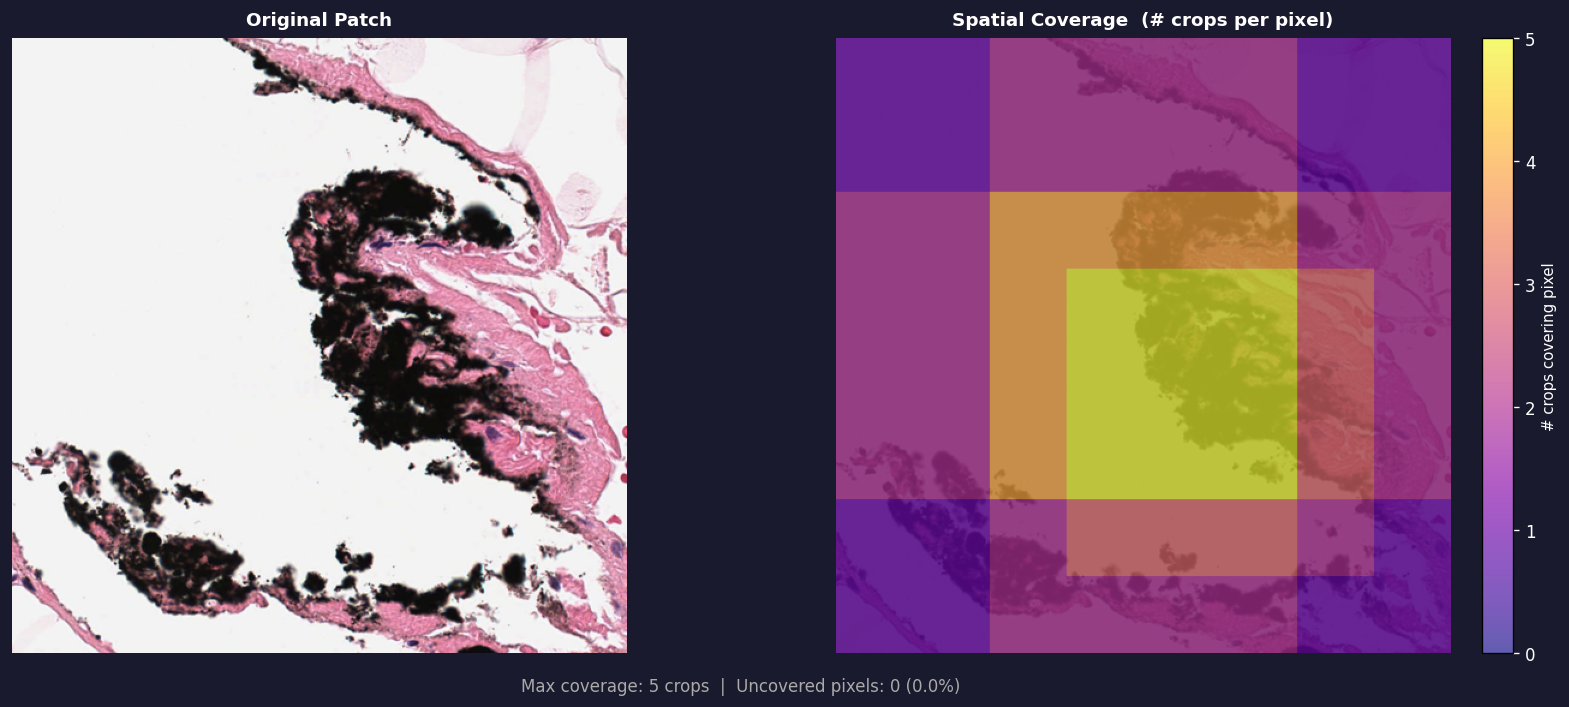

In [10]:
coverage = np.zeros((H, W), dtype=np.float32)

for d in coords:
    l, t = d["left"], d["top"]
    coverage[t : t + CROP_SIZE, l : l + CROP_SIZE] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#1a1a2e")

# Original
axes[0].imshow(np.array(img))
axes[0].set_title("Original Patch", color="white", fontsize=11,
                  fontweight="bold", pad=8)
axes[0].axis("off")

# Coverage heatmap overlaid
axes[1].imshow(np.array(img), alpha=0.35)
im2 = axes[1].imshow(coverage, cmap="plasma", alpha=0.65,
                     vmin=0, vmax=coverage.max())
cb  = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label("# crops covering pixel", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cb.ax.axes, "yticklabels"), color="white")

axes[1].set_title("Spatial Coverage  (# crops per pixel)",
                  color="white", fontsize=11, fontweight="bold", pad=8)
axes[1].axis("off")

for ax in axes:
    ax.set_facecolor("#1a1a2e")

fig.suptitle(
    f"Max coverage: {int(coverage.max())} crops  |  "
    f"Uncovered pixels: {int((coverage == 0).sum())} "
    f"({100*(coverage==0).mean():.1f}%)",
    color="#aaaaaa", fontsize=10, y=0
)
plt.tight_layout()
plt.show()

## 11 · (Optional) Save All Crops to Disk

In [ ]:
SAVE_CROPS = False          # ← set True to save crops
SAVE_DIR   = "tencrop_out"  # output folder

if SAVE_CROPS:
    os.makedirs(SAVE_DIR, exist_ok=True)
    stem = os.path.splitext(os.path.basename(PATCH_PATH))[0]
    for i, (crop_img, d) in enumerate(zip(crops, coords)):
        fname = f"{stem}_crop{i+1:02d}_{d['label'].split('·')[1].strip().replace(' ','_')}.png"
        crop_img.save(os.path.join(SAVE_DIR, fname))
    print(f"✅  Saved {len(crops)} crops → {SAVE_DIR}/")
else:
    print("ℹ️   Set SAVE_CROPS = True to write crops to disk.")

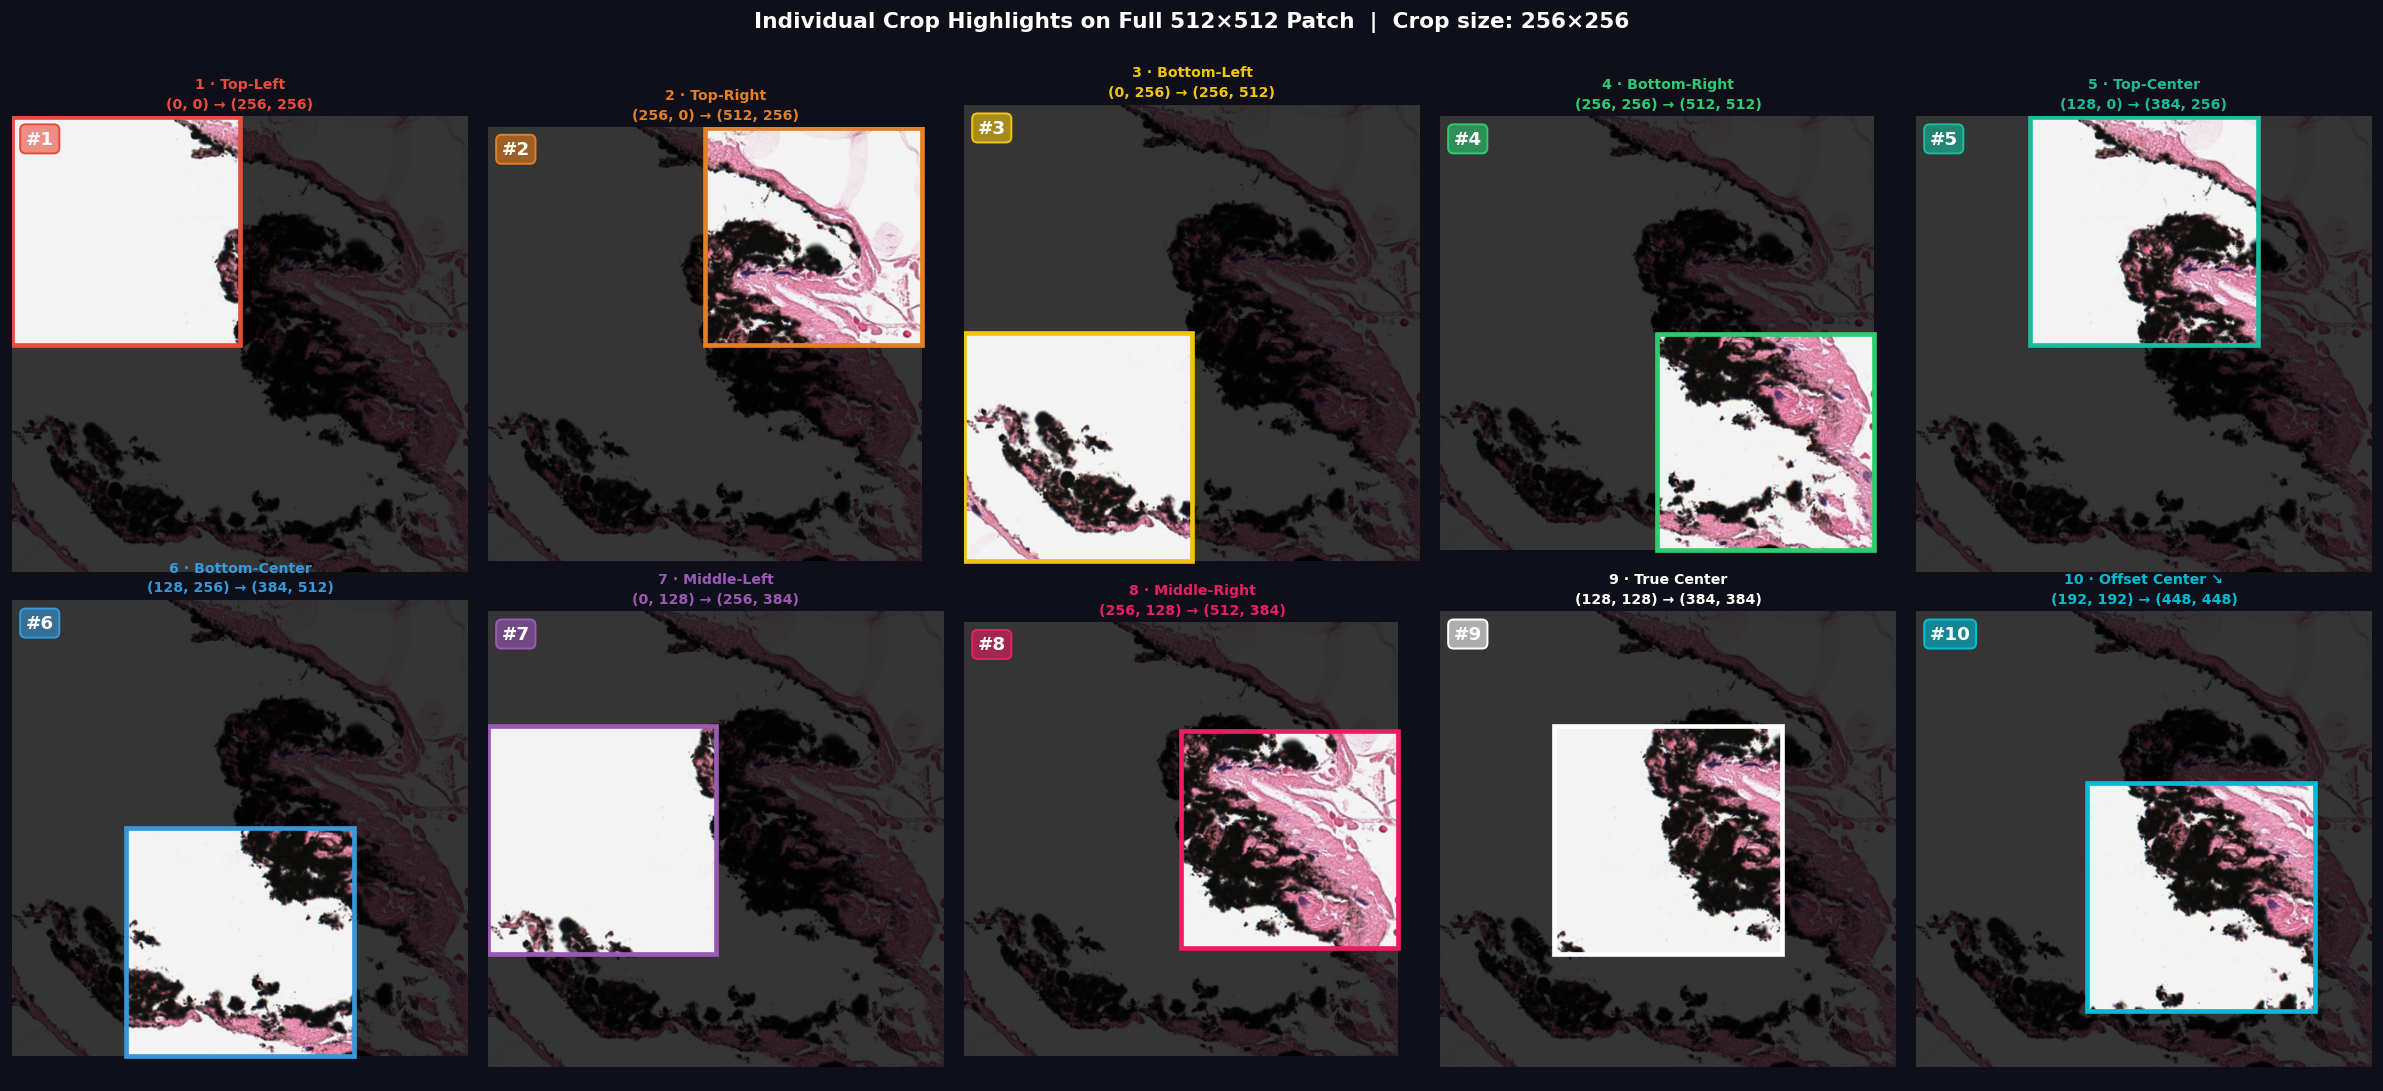

In [11]:
# ── Individual Crop Highlight — each crop shown on the full patch ─────────
#
# Layout: 2 rows × 5 cols
# Each subplot = full 512×512 patch with ONE crop region lit up,
# rest of the image dimmed to 30%.
# ─────────────────────────────────────────────────────────────────────────

img_arr = np.array(img)           # (H, W, 3)  full patch as numpy

fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 9),
    facecolor="#0f0f1a"
)

fig.suptitle(
    f"Individual Crop Highlights on Full {W}×{H} Patch  |  "
    f"Crop size: {CROP_SIZE}×{CROP_SIZE}",
    color="white", fontsize=13, fontweight="bold", y=1.01
)

for idx, (d, crop_img) in enumerate(zip(coords, crops)):
    row, col = divmod(idx, 5)
    ax = axes[row][col]

    l, t   = d["left"], d["top"]
    c_col  = d["color"]
    c_size = CROP_SIZE

    # ── Build highlight composite ──────────────────────────────────────
    # Start with a dimmed version of the full patch
    dimmed = (img_arr * 0.22).astype(np.uint8)

    # Paste the original (bright) pixels back only for this crop region
    composite = dimmed.copy()
    composite[t : t + c_size, l : l + c_size] = \
        img_arr[t : t + c_size, l : l + c_size]

    # ── Draw the composite ─────────────────────────────────────────────
    ax.imshow(composite)
    ax.set_facecolor("#0f0f1a")
    ax.axis("off")

    # Coloured rectangle border around the highlighted crop
    rect = mpatches.FancyBboxPatch(
        (l, t), c_size, c_size,
        linewidth=2.8,
        edgecolor=c_col,
        facecolor="none",
        boxstyle="square,pad=0",
        zorder=3
    )
    ax.add_patch(rect)

    # Small corner tick marks for precision reference
    tick = c_size * 0.08
    for (sx, sy, dx, dy) in [
        (l,          t,          1,  1),   # top-left
        (l + c_size, t,         -1,  1),   # top-right
        (l,          t + c_size, 1, -1),   # bottom-left
        (l + c_size, t + c_size,-1, -1),   # bottom-right
    ]:
        ax.plot([sx, sx + dx*tick], [sy, sy],
                color=c_col, lw=1.8, zorder=4)
        ax.plot([sx, sx],           [sy, sy + dy*tick],
                color=c_col, lw=1.8, zorder=4)

    # Title — label + pixel coordinates
    ax.set_title(
        f"{d['label']}\n({l}, {t}) → ({l+c_size}, {t+c_size})",
        color=c_col,
        fontsize=8.5,
        fontweight="bold",
        pad=5,
        linespacing=1.5
    )

    # Crop index badge — top-left corner of the subplot
    ax.text(
        0.03, 0.97,
        f"#{idx + 1}",
        transform=ax.transAxes,
        color="white",
        fontsize=11,
        fontweight="bold",
        va="top",
        bbox=dict(
            facecolor=c_col + "99",
            edgecolor=c_col,
            boxstyle="round,pad=0.3",
            linewidth=1.2
        )
    )

    # Spine border matching crop colour
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(c_col)
        spine.set_linewidth(2.5)

plt.tight_layout(pad=1.2)
plt.show()